In [1]:
%run prelude.py

Unable to load CXX API! No module named 'gaps_tof'


INFO:numexpr.utils:Note: NumExpr detected 32 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 16.
INFO:numexpr.utils:NumExpr defaulting to 16 threads.


In [2]:
runs  = { 9125 : {'start' : 1734094131 , 'end' : 1734113466, 'data_dir' : Path('/data2/gaps/gcu')}}
runid = 9125

data = go.run.load_run_from_telemetry(**runs[runid])

-> Found 19460 files in /data2/gaps/gcu
-> Run duration 5:18:47
-> Found 362 files within range of 2024-12-13 12:48:51+00:00 - 2024-12-13 18:11:06+00:00
--> Earliest file /data2/gaps/gcu/RAW241213_124932.bin
--> Latest file /data2/gaps/gcu/RAW241213_180819.bin


Filtering....: 100%|██████████████████████| 7651807/7651807 [00:00<00:00, 11140552.59it/s]


--> Found 17702417 packets in the binary files
--> During unpacking, we encountered 8125 de-serialization errors!
--> We got 7643682 merged events in this run
--> Compared to a consecutive rising event id, we lost 0.04% events!


In [4]:
print (data.keys())

dict_keys(['files', 'errors', 'events', 'mtbmoni', 'rbmoni'])


In [9]:
tofevents = [k.tof for k in data['events']]
occu = go.tof.analysis.create_occupancy_dict(events = tofevents)

Getting TOF occupancy data!: 100%|█████████| 7643682/7643682 [00:05<00:00, 1377419.24it/s]


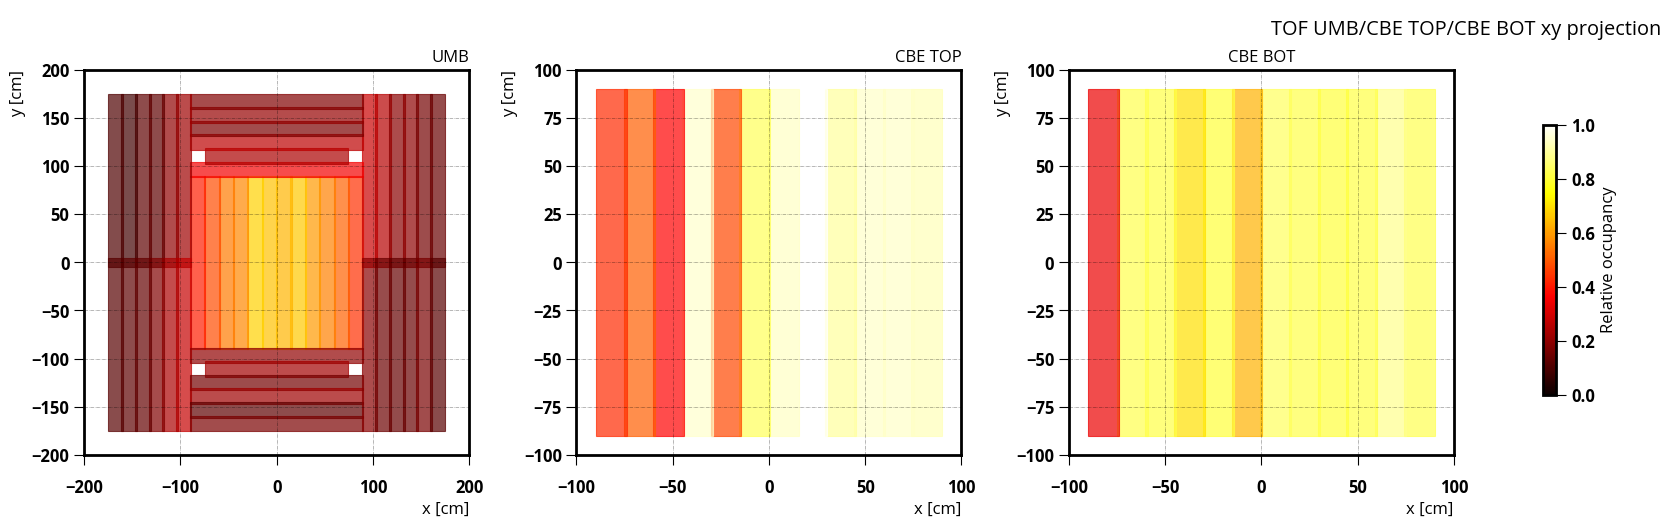

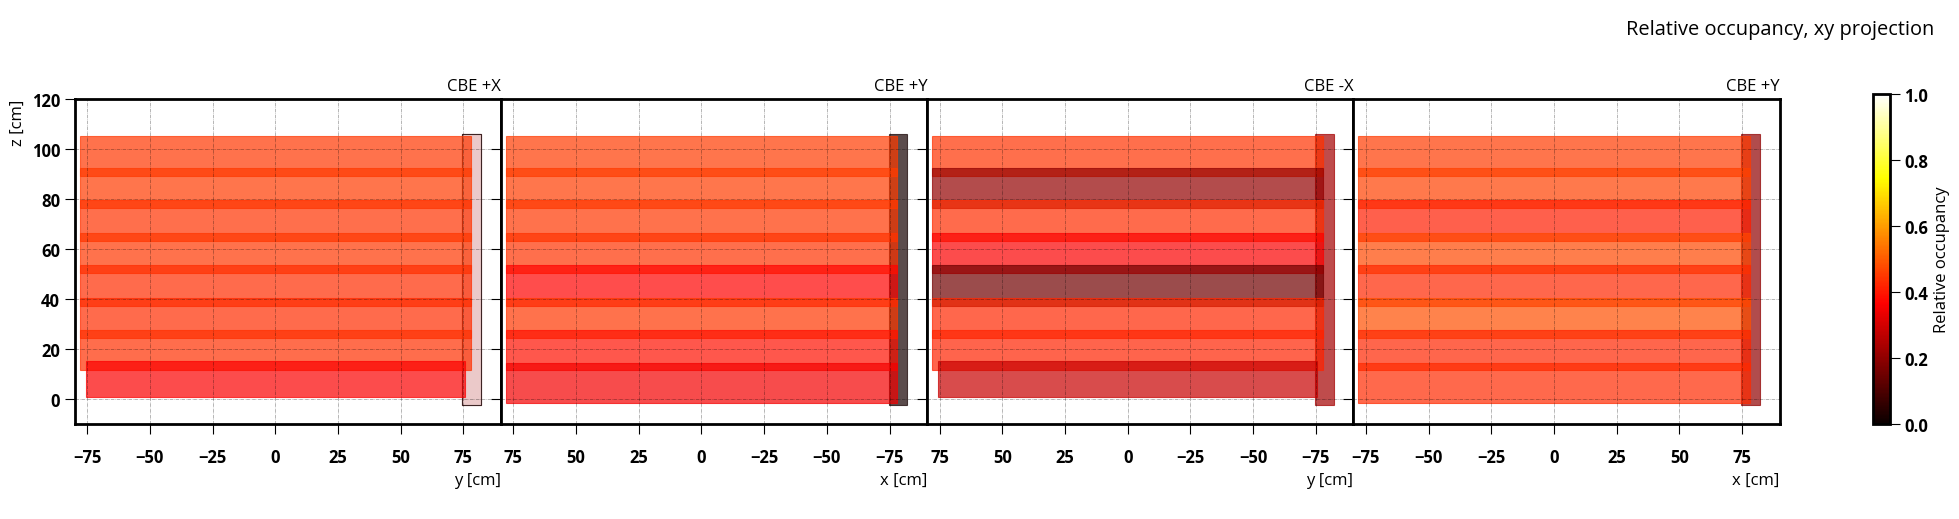

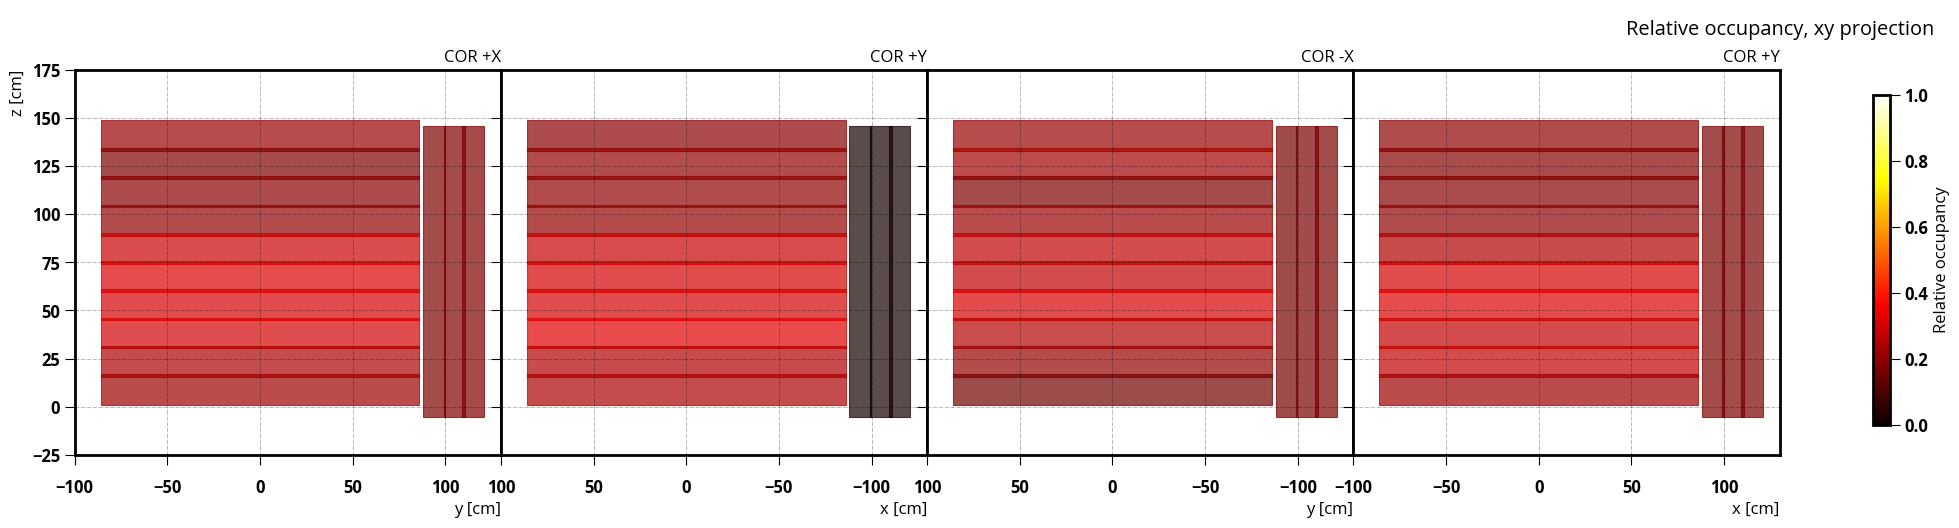

In [16]:
%matplotlib inline

fig, ax = go.tof.visual.tof_projection_xy(occu)
fig, ax = go.tof.visual.unroll_cbe_sides(paddle_occupancy=occu)
fig, ax = go.tof.visual.unroll_cor(paddle_occupancy=occu)